In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from IPython.display import display
import random
import hashlib

USERNAME = "muskan.sharma"
CSV_PATH = "stars_data.csv" 
REPO_NAMES = ["facebook/react", "pallets/flask"]
WINDOW_SIZE = 30
HORIZONS = [1, 3, 7, 14]
EPOCHS = 50
BATCH_SIZE = 16
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = int(hashlib.sha256(USERNAME.encode()).hexdigest(), 16) % (2**32)

print(f"Running on device: {DEVICE}")

Running on device: cpu


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

: 

: 

: 

### Data preprocessing

In [ ]:
class StarPreprocessor:
    def __init__(self, csv_path):
        self.csv_path = csv_path
        self.raw_df = None

    def load_data(self):
        self.raw_df = pd.read_csv(self.csv_path, parse_dates=['timestamp'])
        self.raw_df.columns = self.raw_df.columns.str.strip()
        self.raw_df = self.raw_df.sort_values('timestamp')
        
        self.raw_df['date_only'] = self.raw_df['timestamp'].dt.date
        
        # Drop duplicates: Keep the LAST entry for every (Repo, Date) pair.
        self.raw_df = self.raw_df.drop_duplicates(
            subset=['repository_id', 'date_only'], 
            keep='last'
        )
        self.raw_df = self.raw_df.drop(columns=['date_only'])

    def get_repo_series(self, repo_name):
        repo_df = self.raw_df[self.raw_df['repository_id'] == repo_name].copy()
        
        if repo_df.empty:
            raise ValueError(f"Repository '{repo_name}' not found.")

        repo_df = repo_df.set_index('timestamp')
        daily_series = repo_df['stars'].resample('D').max()
        daily_series = daily_series.ffill().fillna(0)

        # Incremental Domain (Stationary)
        incremental_series = daily_series.diff().fillna(0)
        
        return daily_series, incremental_series

    def normalize_series(self, train_data, test_data):
        self.min_val = train_data.min()
        self.max_val = train_data.max()
        
        if self.max_val == self.min_val:
            return train_data, test_data

        train_scaled = (train_data - self.min_val) / (self.max_val - self.min_val)
        test_scaled = (test_data - self.min_val) / (self.max_val - self.min_val)
        
        return train_scaled, test_scaled

    def inverse_transform(self, scaled_data):
        return scaled_data * (self.max_val - self.min_val) + self.min_val

: 

### Data Split

In [ ]:
def chronological_split(data, split_ratio=0.8):
    split_point = int(len(data) * split_ratio)
    train = data[:split_point]
    test = data[split_point:]
    return train, test

: 

### Forecasting models
#### ARMA

In [ ]:
class ClassicalARMA:
    def __init__(self, order=(2, 0, 2)):
        self.order = order
        self.model = None
        self.fit_result = None

    def fit(self, train_data):
        # Train on incremental data (stationary)
        clean_data = np.array(train_data)
        self.model = ARIMA(clean_data, order=self.order)
        self.fit_result = self.model.fit()

    def forecast(self, steps):
        if self.fit_result is None: raise ValueError("Model not fit.")
        return self.fit_result.forecast(steps=steps)

: 

#### RNN and 1D CNN

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        # Take only the last time step
        return self.fc(out[:, -1, :])

class SimpleCNN(nn.Module):
    def __init__(self, input_dim=1, num_filters=32, kernel_size=3, output_dim=1, seq_len=30):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=num_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        conv_out_size = seq_len - kernel_size + 1
        self.fc = nn.Linear(num_filters * conv_out_size, output_dim)

    def forward(self, x):
        # [batch, channels, seq_len]
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.flatten(x)
        return self.fc(x)

: 

In [ ]:
def create_sliding_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

def train_dl_model(model, train_data, window_size):
    X, y = create_sliding_windows(train_data, window_size)
    
    X_tensor = torch.FloatTensor(X).unsqueeze(-1).to(DEVICE)
    y_tensor = torch.FloatTensor(y).unsqueeze(-1).to(DEVICE)
    
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    model.to(DEVICE)
    
    model.train()
    for epoch in range(EPOCHS):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    return model

def autoregressive_forecast_dl(model, history, horizon, window_size):
    """Generates multi-step forecast by feeding predictions back."""
    model.eval()
    current_seq = torch.FloatTensor(history[-window_size:]).unsqueeze(0).unsqueeze(-1).to(DEVICE)
    predictions = []
    
    with torch.no_grad():
        for _ in range(horizon):
            pred = model(current_seq)
            pred_val = pred.item()
            predictions.append(pred_val)
            
            # Update sequence: remove oldest, add new prediction
            new_input = torch.FloatTensor([[[pred_val]]]).to(DEVICE)
            current_seq = torch.cat((current_seq[:, 1:, :], new_input), dim=1)
    return predictions

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

: 

In [ ]:
def plot_forecasts(train, test, forecasts, labels, title):
    plt.figure(figsize=(12, 6))
    
    plt.plot(train.index[-50:], train.values[-50:], label='Train (Last 50)', color='gray', alpha=0.5)
    plt.plot(test.index, test.values, label='Actual Test', color='black', linewidth=2)
    
    for forecast, label in zip(forecasts, labels):
        f_index = test.index[:len(forecast)]
        plt.plot(f_index, forecast, label=label, linestyle='--')

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("New Stars (Incremental)")
    plt.legend()
    plt.text(0.95, 0.95, USERNAME, ha='right', va='top', 
             transform=plt.gca().transAxes, fontsize=10, color='gray', alpha=0.7)
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_error_vs_horizon(metrics_dict, repo_name):
    plt.figure(figsize=(8, 5))
    for model_name, data in metrics_dict.items():
        horizons = sorted(data.keys())
        errors = [data[h] for h in horizons]
        plt.plot(horizons, errors, marker='o', label=model_name)
        
    plt.title(f"RMSE vs Forecast Horizon ({repo_name})")
    plt.xlabel("Horizon (Days)")
    plt.ylabel("RMSE")
    plt.legend()
    plt.text(0.95, 0.95, USERNAME, ha='right', va='top', 
             transform=plt.gca().transAxes, fontsize=10, color='gray', alpha=0.7)
    plt.grid(True)
    plt.show()

: 

Processing: facebook/react
Train Samples: 3633 | Test Samples: 909


/Users/muskansh/Desktop/IIIT-Hyd/asg1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE Results: {'ARMA': {1: np.float64(0.000140780881339838), 3: np.float64(0.0001734376037126687), 7: np.float64(0.0002447899051897226), 14: np.float64(0.0003723531499412137)}, 'RNN': {1: np.float64(0.00014455430209636688), 3: np.float64(0.00023028048096715954), 7: np.float64(0.00028721218719939803), 14: np.float64(0.0003270493114638086)}, 'CNN': {1: np.float64(0.0007488913834095001), 3: np.float64(0.0009898371576147259), 7: np.float64(0.0013805216692818912), 14: np.float64(0.002217472981580305)}}


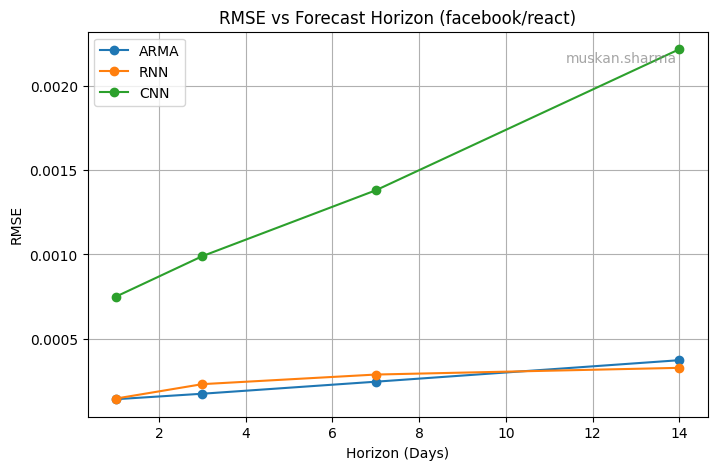

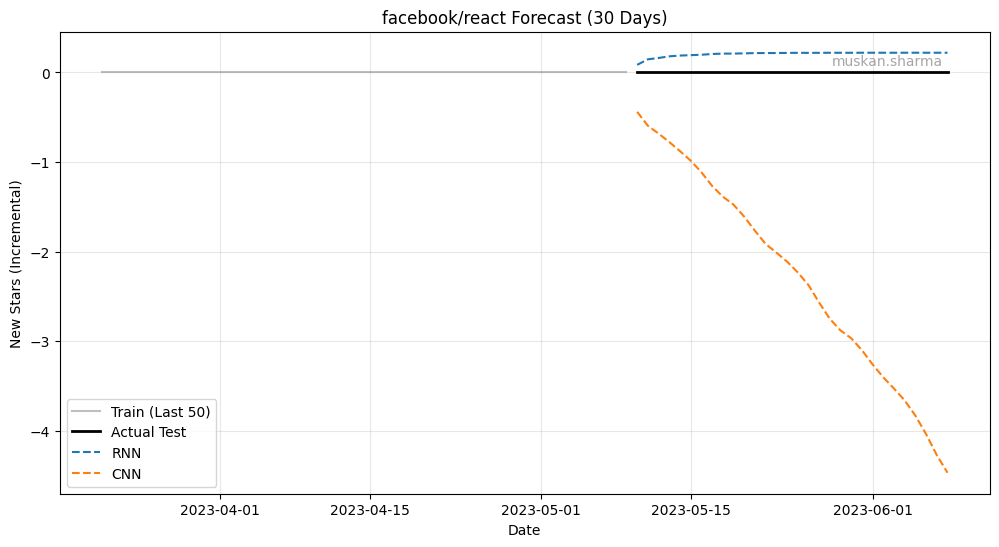

FINAL RESULTS TABLE: facebook/react


Model,ARMA,CNN,RNN
Horizon (Days),,,
1,0.000141,0.000749,0.000145
3,0.000173,0.000990,0.000230
7,0.000245,0.001381,0.000287
14,0.000372,0.002217,0.000327


Processing: pallets/flask
Train Samples: 4552 | Test Samples: 1139


/Users/muskansh/Desktop/IIIT-Hyd/asg1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/muskansh/Desktop/IIIT-Hyd/asg1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/muskansh/Desktop/IIIT-Hyd/asg1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE Results: {'ARMA': {1: np.float64(0.0014814391868127469), 3: np.float64(0.0015556451823930647), 7: np.float64(0.0016746859196010504), 14: np.float64(0.0018804236362557523)}, 'RNN': {1: np.float64(0.0002662837505340576), 3: np.float64(0.00029557474242283876), 7: np.float64(0.0003494312620089643), 14: np.float64(0.00041748491438117747)}, 'CNN': {1: np.float64(0.006837233901023865), 3: np.float64(0.005840731274421996), 7: np.float64(0.006832587037537327), 14: np.float64(0.008948031530622147)}}


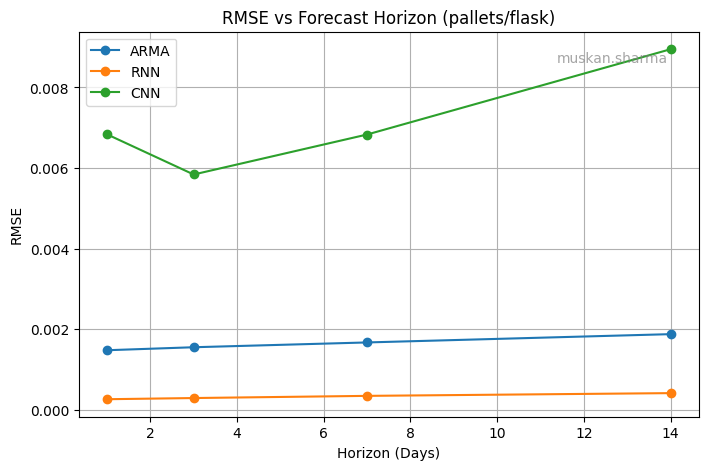

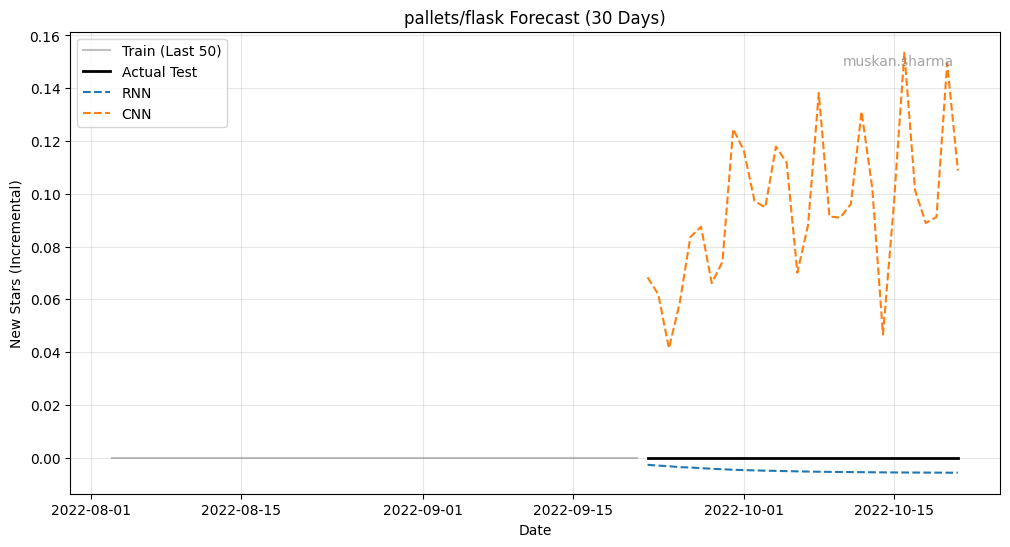

FINAL RESULTS TABLE: pallets/flask


Model,ARMA,CNN,RNN
Horizon (Days),,,
1,0.001481,0.006837,0.000266
3,0.001556,0.005841,0.000296
7,0.001675,0.006833,0.000349
14,0.001880,0.008948,0.000417


In [12]:
preprocessor = StarPreprocessor(CSV_PATH)
preprocessor.load_data()

for repo in REPO_NAMES:
    print(f"Processing: {repo}")
    
    daily, incremental = preprocessor.get_repo_series(repo)
    train_raw, test_raw = chronological_split(incremental, split_ratio=0.8)
    train_scaled, test_scaled = preprocessor.normalize_series(train_raw.values, test_raw.values)
    
    print(f"Train Samples: {len(train_scaled)} | Test Samples: {len(test_scaled)}")
    
    # Train Models
    # ARMA
    arma = ClassicalARMA()
    try:
        arma.fit(train_scaled)
    except:
        print("ARMA failed to converge.")
        
    # RNN
    rnn = SimpleRNN().to(DEVICE)
    rnn = train_dl_model(rnn, train_scaled, WINDOW_SIZE)
    
    # CNN
    cnn = SimpleCNN(seq_len=WINDOW_SIZE).to(DEVICE)
    cnn = train_dl_model(cnn, train_scaled, WINDOW_SIZE)
    
    # Evaluate
    results = {'ARMA': {}, 'RNN': {}, 'CNN': {}}
    history_seed = train_scaled[-WINDOW_SIZE:]
    
    for h in HORIZONS:
        if len(test_scaled) < h: break
        y_true = test_scaled[:h]
        
        # ARMA
        try:
            pred_arma = arma.forecast(h)
            _, results['ARMA'][h] = calculate_metrics(y_true, pred_arma)
        except: results['ARMA'][h] = np.nan
            
        # RNN
        pred_rnn = autoregressive_forecast_dl(rnn, history_seed, h, WINDOW_SIZE)
        _, results['RNN'][h] = calculate_metrics(y_true, pred_rnn)
        
        # CNN
        pred_cnn = autoregressive_forecast_dl(cnn, history_seed, h, WINDOW_SIZE)
        _, results['CNN'][h] = calculate_metrics(y_true, pred_cnn)
        
    print("RMSE Results:", results)
    
    # Plotting
    plot_error_vs_horizon(results, repo)
    
    # Trajectory Plot (30 Days)
    long_h = 30
    if len(test_scaled) >= long_h:
        rnn_long = autoregressive_forecast_dl(rnn, history_seed, long_h, WINDOW_SIZE)
        cnn_long = autoregressive_forecast_dl(cnn, history_seed, long_h, WINDOW_SIZE)
        
        # Inverse scaling
        rnn_real = preprocessor.inverse_transform(np.array(rnn_long))
        cnn_real = preprocessor.inverse_transform(np.array(cnn_long))
        
        # Prepare Test Data for plot
        test_real_vals = preprocessor.inverse_transform(test_scaled[:long_h])
        test_series = pd.Series(test_real_vals, index=test_raw.index[:long_h])
        
        plot_forecasts(
            train_raw, test_series, [rnn_real, cnn_real], 
            ['RNN', 'CNN'], f"{repo} Forecast (30 Days)"
        )
    
    print(f"FINAL RESULTS TABLE: {repo}")

    table_data = []
    for model_name in ['ARMA', 'RNN', 'CNN']:
        for h in HORIZONS:
            if h in results[model_name]:
                error_val = results[model_name][h]
                table_data.append({
                    "Model": model_name,
                    "Horizon (Days)": h,
                    "RMSE": error_val
                })

    df_results = pd.DataFrame(table_data)
    summary_table = df_results.pivot(index="Horizon (Days)", columns="Model", values="RMSE")
    display(summary_table)